# Behavioral Diversity Analysis

This notebook investigates two questions about how feedback format affects the evolutionary search:

1. **Behavioral steering of the best algorithm**: Does the best algorithm per run exhibit the desired behavioral property? Did the guided feature move in the right direction (directional) or reach the target value (comparative)?

2. **Search space diversity**: Does prescriptive feedback narrow the diversity of generated algorithms, limiting exploration of the design space?

Sections 1–3 analyze steering effectiveness on the best candidate. Sections 4–6 analyze aggregate pairwise diversity.

In [1]:
import sys
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd()))
from export_figures import (
    load_phase3,
    PASTEL_PALETTE, FORMAT_COLORS, FEATURES, FORMATS,
    VANILLA_AOCC, N_SEEDS, SAVEFIG_KW, FEATURE_SHORT,
    FONT_SIZE_BASE, FONT_SIZE_TITLE, FONT_SIZE_LABEL,
    FONT_SIZE_TICK, FONT_SIZE_LEGEND,
    formats_for_feature, COMPARATIVE_EXCLUDE,
)
from experiments.feedback import FEATURE_DIRECTIONS, FEATURE_REFERENCES

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "legend.fontsize": FONT_SIZE_LEGEND,
    "font.family": "serif",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.5,
    "axes.grid": False,
})

df = load_phase3()
print(f"Loaded {len(df)} evaluations, {df['condition'].nunique()} conditions")

# Identify behavioral feature columns
bf_cols = sorted([c for c in df.columns if c.startswith("bf_")])
print(f"Behavioral feature columns: {len(bf_cols)}")

# Coerce bf_* columns to numeric (some JSONL values are string 'nan')
for col in bf_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop bf columns with >50% NaN
nan_frac = df[bf_cols].isna().mean()
bf_cols = [c for c in bf_cols if nan_frac[c] <= 0.5]
print(f"After dropping high-NaN columns: {len(bf_cols)}")

Loaded 14500 evaluations, 29 conditions
Behavioral feature columns: 32
After dropping high-NaN columns: 29


In [2]:
def cliffs_delta(x, y):
    """Cliff's delta effect size."""
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)


def effect_label(d):
    d = abs(d)
    if d < 0.147:
        return "negligible"
    elif d < 0.33:
        return "small"
    elif d < 0.474:
        return "medium"
    else:
        return "large"

## 1. Best-Candidate Behavioral Steering

For each run (condition × seed), we find the best algorithm by AOCC and check whether its guided behavioral feature value:
- **Directional**: moved in the advised direction relative to neutral's best
- **Comparative**: reached (or exceeded) the top-10% reference value

In [3]:
# For each run, find the best algorithm (highest AOCC) and record its guided feature value
best_rows = []
for (cond, seed), grp in df.groupby(["condition", "seed"]):
    fmt = cond.split("-", 1)[0]
    feat = cond.split("-", 1)[1]
    bf_col = f"bf_{feat}"
    if bf_col not in df.columns:
        continue

    valid = grp[~grp["failed"]].copy()
    if valid.empty:
        continue

    best_idx = valid["fitness"].idxmax()
    best_row = valid.loc[best_idx]

    best_rows.append({
        "condition": cond,
        "format": fmt,
        "feature": feat,
        "seed": seed,
        "best_aocc": best_row["fitness"],
        "best_eval": best_row["evaluation"],
        "best_bf_value": best_row[bf_col],
    })

best_df = pd.DataFrame(best_rows)
print(f"Best-candidate records: {len(best_df)}")

# Build the steering summary table
steering_rows = []
for feat in FEATURES:
    direction = FEATURE_DIRECTIONS[feat][0]  # "higher" or "lower"
    top_ref = FEATURE_REFERENCES.get(feat, (None, None))[0]

    # Neutral baseline: median of best-candidate feature values across seeds
    neutral_vals = best_df[(best_df["feature"] == feat) & (best_df["format"] == "neutral")]["best_bf_value"].dropna()
    neutral_median = neutral_vals.median() if len(neutral_vals) > 0 else np.nan

    for fmt in formats_for_feature(feat):
        fmt_vals = best_df[(best_df["feature"] == feat) & (best_df["format"] == fmt)]["best_bf_value"].dropna()
        fmt_aocc = best_df[(best_df["feature"] == feat) & (best_df["format"] == fmt)]["best_aocc"].dropna()
        fmt_median = fmt_vals.median() if len(fmt_vals) > 0 else np.nan

        # Directional check: did it move in the advised direction relative to neutral?
        if fmt == "neutral":
            dir_steered = "—"
        elif direction == "higher":
            dir_steered = "✓" if fmt_median > neutral_median else "✗"
        else:
            dir_steered = "✓" if fmt_median < neutral_median else "✗"

        # Comparative check: did it reach the top-10% reference?
        if fmt == "neutral" or top_ref is None:
            comp_steered = "—"
        elif direction == "higher":
            comp_steered = "✓" if fmt_median >= top_ref else f"✗ ({fmt_median:.4f} vs {top_ref:.4f})"
        else:
            comp_steered = "✓" if fmt_median <= top_ref else f"✗ ({fmt_median:.4f} vs {top_ref:.4f})"

        steering_rows.append({
            "Feature": FEATURE_SHORT[feat],
            "Format": fmt,
            "AOCC (median)": f"{fmt_aocc.median():.3f}" if len(fmt_aocc) > 0 else "—",
            "BF (median)": f"{fmt_median:.4f}" if not np.isnan(fmt_median) else "—",
            "Neutral BF": f"{neutral_median:.4f}" if not np.isnan(neutral_median) else "—",
            "Dir. steered": dir_steered,
            "Reached ref": comp_steered,
        })

steering_table = pd.DataFrame(steering_rows)
print("\nBest-Candidate Steering (median of best algorithm's guided feature value per run):")
print(steering_table.to_string(index=False))

Best-candidate records: 145

Best-Candidate Steering (median of best algorithm's guided feature value per run):
       Feature      Format AOCC (median) BF (median) Neutral BF Dir. steered          Reached ref
      avg_impr     neutral         0.908      0.0962     0.0962            —                    —
      avg_impr directional         0.901      0.0955     0.0962            ✓                    ✓
      avg_impr comparative         0.896      0.0929     0.0962            ✓                    ✓
  intens_ratio     neutral         0.904      0.8782     0.8782            —                    —
  intens_ratio directional         0.789      0.8937     0.8782            ✓                    ✓
  intens_ratio comparative         0.743      0.8352     0.8782            ✗ ✗ (0.8352 vs 0.8654)
  plateau_frac     neutral         0.892      0.5648     0.5648            —                    —
  plateau_frac directional         0.887      0.3533     0.5648            ✗ ✗ (0.3533 vs 0.5873)
  plat

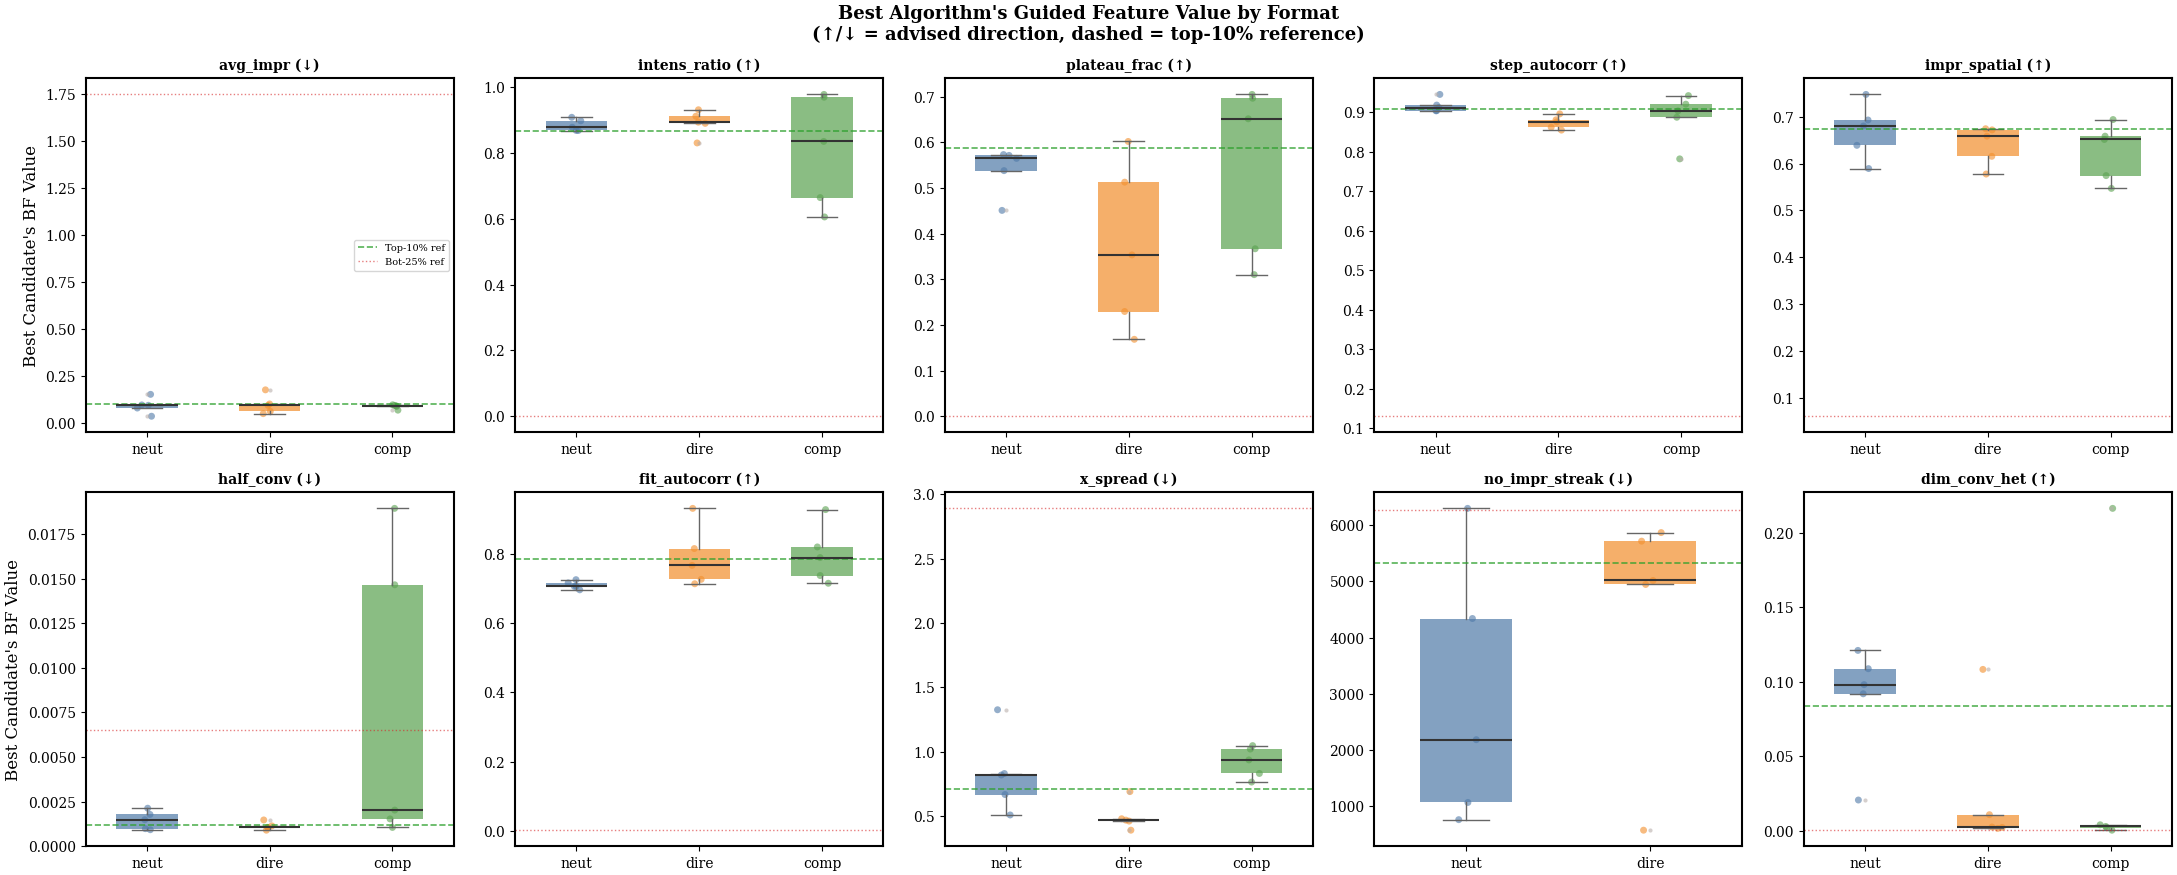

In [4]:
# Visualize best-candidate guided feature values per feature, with reference lines
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

rng = np.random.default_rng(42)

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    direction = FEATURE_DIRECTIONS[feat][0]
    top_ref, bot_ref = FEATURE_REFERENCES.get(feat, (None, None))
    fmts = formats_for_feature(feat)

    fmt_data = []
    for fmt in fmts:
        vals = best_df[(best_df["feature"] == feat) & (best_df["format"] == fmt)]["best_bf_value"].dropna().values
        fmt_data.append(vals)

    if all(len(d) == 0 for d in fmt_data):
        ax.set_title(FEATURE_SHORT[feat], fontsize=FONT_SIZE_TICK)
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
        continue

    bp = ax.boxplot(fmt_data, labels=[f[:4] for f in fmts], patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color="#333333", linewidth=1.5),
                    whiskerprops=dict(color="#666666"),
                    capprops=dict(color="#666666"),
                    flierprops=dict(marker="o", markerfacecolor="#bab0ac",
                                    markeredgecolor="none", markersize=3, alpha=0.6))
    for patch, fmt in zip(bp["boxes"], fmts):
        patch.set_facecolor(FORMAT_COLORS[fmt])
        patch.set_edgecolor("none")
        patch.set_alpha(0.7)

    # Overlay individual points
    for j, fmt in enumerate(fmts):
        vals = fmt_data[j]
        if len(vals) > 0:
            jitter = rng.normal(0, 0.04, size=len(vals))
            ax.scatter(np.full_like(vals, j + 1) + jitter, vals,
                      alpha=0.6, s=25, color=FORMAT_COLORS[fmt], edgecolor="none")

    # Reference lines
    if top_ref is not None:
        ax.axhline(y=top_ref, color="#2ca02c", linestyle="--", linewidth=1.2, alpha=0.8, label="Top-10% ref")
    if bot_ref is not None:
        ax.axhline(y=bot_ref, color="#d62728", linestyle=":", linewidth=1.0, alpha=0.6, label="Bot-25% ref")

    # Direction arrow annotation
    arrow = "↑" if direction == "higher" else "↓"
    ax.set_title(f"{FEATURE_SHORT[feat]} ({arrow})", fontsize=FONT_SIZE_TICK, fontweight="bold")

    if idx % 5 == 0:
        ax.set_ylabel("Best Candidate's BF Value")

    if idx == 0:
        ax.legend(fontsize=7, loc="best")

fig.suptitle("Best Algorithm's Guided Feature Value by Format\n(↑/↓ = advised direction, dashed = top-10% reference)",
             fontweight="bold", fontsize=FONT_SIZE_TITLE)
plt.tight_layout()
plt.show()

## 2. Best-So-Far Feature Trajectory Over Generations

Track the guided feature value of the best-so-far algorithm at each evaluation. Does it converge toward the target by the end of the run, even if the mean across all candidates didn't?

Trajectory records: 14500


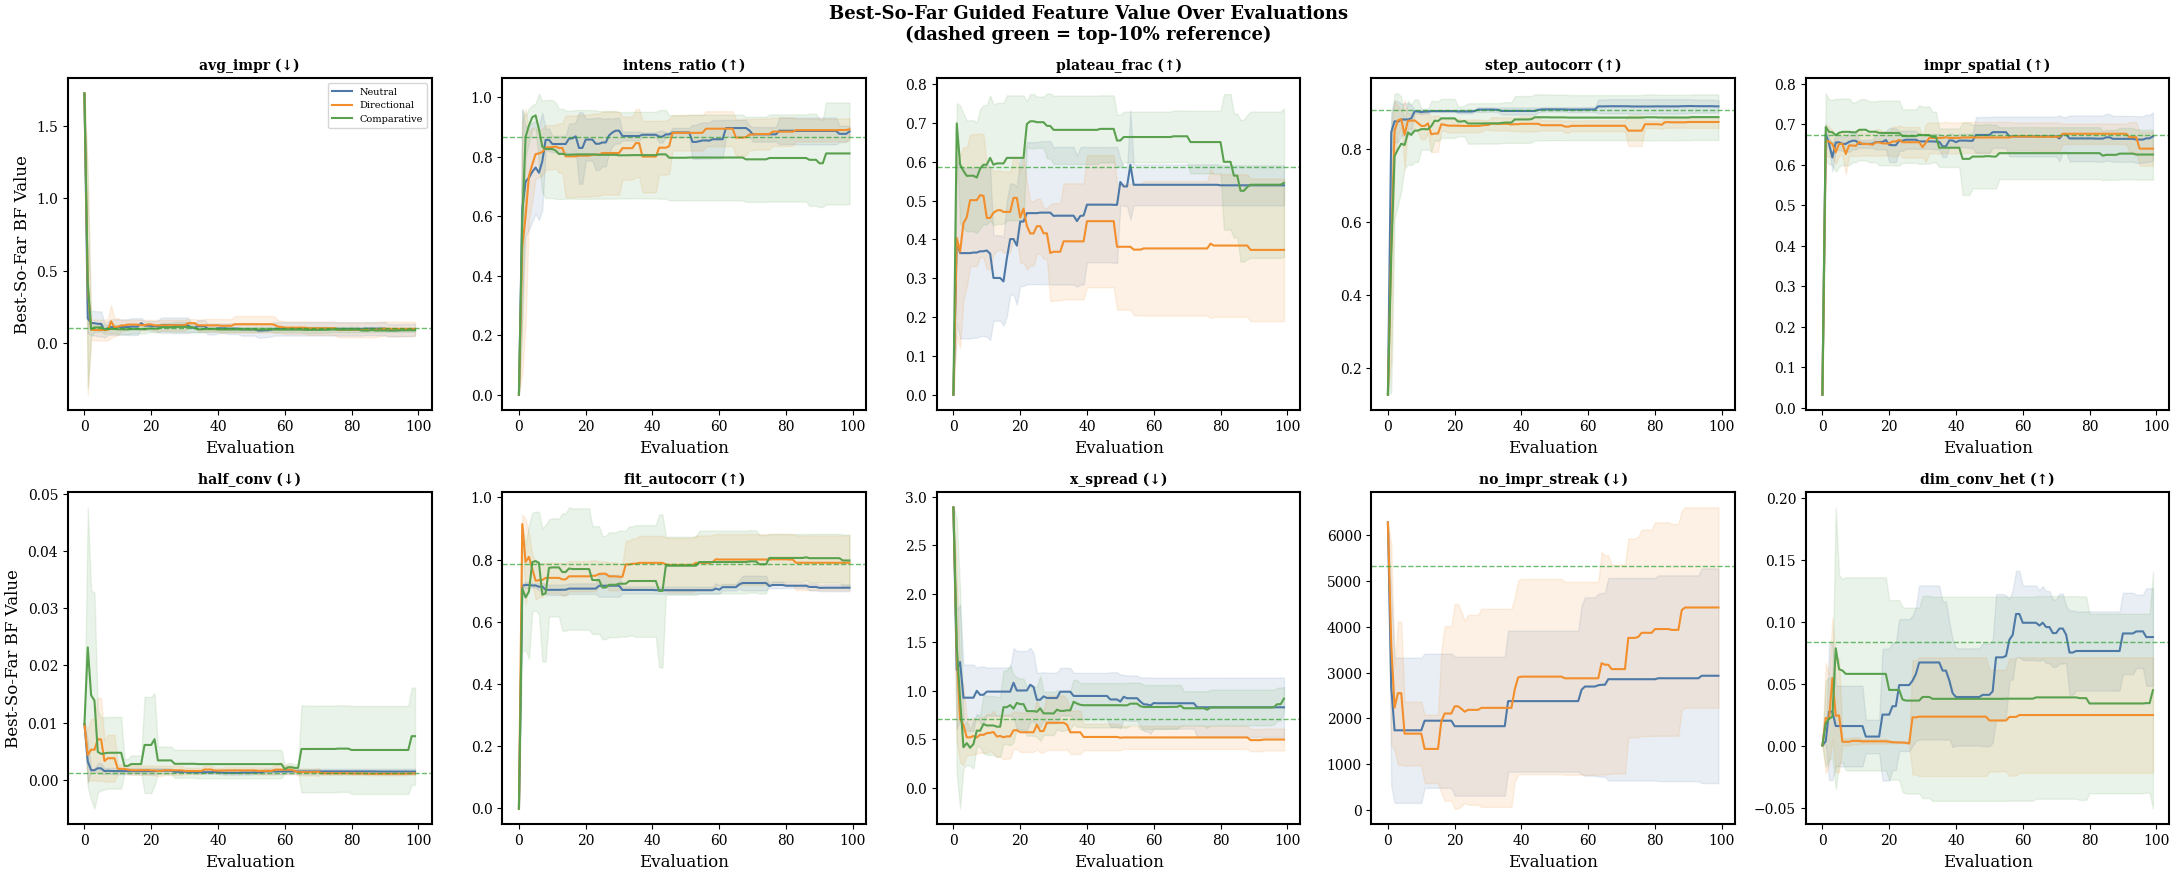

In [5]:
# Compute best-so-far guided feature trajectory for each run
# At each evaluation, the "best-so-far" is the candidate with the highest AOCC seen so far.
# We record the guided feature value of that best-so-far candidate.

trajectory_rows = []
for (cond, seed), grp in df.groupby(["condition", "seed"]):
    fmt = cond.split("-", 1)[0]
    feat = cond.split("-", 1)[1]
    bf_col = f"bf_{feat}"
    if bf_col not in df.columns:
        continue

    grp = grp.sort_values("evaluation").reset_index(drop=True)
    best_fitness = -np.inf
    best_bf = np.nan

    for _, row in grp.iterrows():
        if not row["failed"] and row["fitness"] > best_fitness:
            best_fitness = row["fitness"]
            val = row[bf_col]
            if not (isinstance(val, float) and np.isnan(val)):
                best_bf = val

        trajectory_rows.append({
            "condition": cond,
            "format": fmt,
            "feature": feat,
            "seed": seed,
            "evaluation": row["evaluation"],
            "best_so_far_bf": best_bf,
            "best_so_far_aocc": best_fitness if best_fitness > -np.inf else np.nan,
        })

traj_df = pd.DataFrame(trajectory_rows)
print(f"Trajectory records: {len(traj_df)}")

# Plot: 2x5 grid, one per feature, lines = format mean ± std of best-so-far BF value
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    direction = FEATURE_DIRECTIONS[feat][0]
    top_ref = FEATURE_REFERENCES.get(feat, (None, None))[0]
    fmts = formats_for_feature(feat)

    for fmt in fmts:
        fmt_traj = traj_df[(traj_df["feature"] == feat) & (traj_df["format"] == fmt)]
        if fmt_traj.empty:
            continue
        agg = fmt_traj.groupby("evaluation")["best_so_far_bf"].agg(["mean", "std"]).reset_index()
        ax.plot(agg["evaluation"], agg["mean"], label=fmt.capitalize(),
                color=FORMAT_COLORS[fmt], linewidth=1.5)
        ax.fill_between(agg["evaluation"],
                        agg["mean"] - agg["std"],
                        agg["mean"] + agg["std"],
                        alpha=0.12, color=FORMAT_COLORS[fmt])

    # Top-10% reference line
    if top_ref is not None:
        ax.axhline(y=top_ref, color="#2ca02c", linestyle="--", linewidth=1.0, alpha=0.7)

    arrow = "↑" if direction == "higher" else "↓"
    ax.set_title(f"{FEATURE_SHORT[feat]} ({arrow})", fontsize=FONT_SIZE_TICK, fontweight="bold")
    ax.set_xlabel("Evaluation")

    if idx % 5 == 0:
        ax.set_ylabel("Best-So-Far BF Value")
    if idx == 0:
        ax.legend(fontsize=7, loc="best")

fig.suptitle("Best-So-Far Guided Feature Value Over Evaluations\n(dashed green = top-10% reference)",
             fontweight="bold", fontsize=FONT_SIZE_TITLE)
plt.tight_layout()
plt.show()

## 3. End-of-Run Steering Accuracy

Compare steering accuracy using the best candidate's feature value vs. the mean/median across all candidates (as in the thesis table). Does looking at just the best algorithm change the picture?

In [6]:
# Compare steering accuracy: best-candidate vs all-candidate median
print("Steering Accuracy Comparison: Best Candidate vs All-Candidate Median")
print("=" * 85)
print(f"{'Feature':<16s} {'Adv':>4s} | {'Dir(best)':>10s} {'Dir(all)':>10s} | {'Comp(best)':>11s} {'Comp(all)':>11s}")
print("-" * 85)

dir_correct_best, dir_correct_all, dir_total = 0, 0, 0
comp_correct_best, comp_correct_all, comp_total = 0, 0, 0

for feat in FEATURES:
    direction = FEATURE_DIRECTIONS[feat][0]
    top_ref = FEATURE_REFERENCES.get(feat, (None, None))[0]
    arrow = "↑" if direction == "higher" else "↓"

    # Neutral baselines
    neutral_best = best_df[(best_df["feature"] == feat) & (best_df["format"] == "neutral")]["best_bf_value"].dropna()
    neutral_all_cands = df[(df["feature"] == feat) & (df["format"] == "neutral") & (~df["failed"])][f"bf_{feat}"].dropna()
    n_best_med = neutral_best.median()
    n_all_med = neutral_all_cands.median()

    results = {"directional": {}, "comparative": {}}

    for fmt in ["directional", "comparative"]:
        if fmt == "comparative" and feat in COMPARATIVE_EXCLUDE:
            results[fmt] = {"best": "—", "all": "—"}
            continue

        # Best-candidate
        fmt_best = best_df[(best_df["feature"] == feat) & (best_df["format"] == fmt)]["best_bf_value"].dropna()
        fb_med = fmt_best.median()

        # All-candidate median
        fmt_all = df[(df["feature"] == feat) & (df["format"] == fmt) & (~df["failed"])][f"bf_{feat}"].dropna()
        fa_med = fmt_all.median()

        if direction == "higher":
            best_ok = fb_med > n_best_med
            all_ok = fa_med > n_all_med
        else:
            best_ok = fb_med < n_best_med
            all_ok = fa_med < n_all_med

        results[fmt]["best"] = "✓" if best_ok else "✗"
        results[fmt]["all"] = "✓" if all_ok else "✗"

        if fmt == "directional":
            dir_total += 1
            dir_correct_best += best_ok
            dir_correct_all += all_ok
        else:
            comp_total += 1
            comp_correct_best += best_ok
            comp_correct_all += all_ok

    d = results["directional"]
    c = results["comparative"]
    print(f"{FEATURE_SHORT[feat]:<16s} {arrow:>4s} | {d.get('best','—'):>10s} {d.get('all','—'):>10s} | {c.get('best','—'):>11s} {c.get('all','—'):>11s}")

print("-" * 85)
print(f"{'Accuracy':<16s} {'':>4s} | {dir_correct_best}/{dir_total:>8d} {dir_correct_all}/{dir_total:>8d} | {comp_correct_best}/{comp_total:>9d} {comp_correct_all}/{comp_total:>9d}")
print()
print(f"Directional: best-candidate {dir_correct_best}/{dir_total}, all-candidate {dir_correct_all}/{dir_total}")
print(f"Comparative: best-candidate {comp_correct_best}/{comp_total}, all-candidate {comp_correct_all}/{comp_total}")

# Also check: for comparative, how many best candidates actually reached the reference?
print("\n\nComparative Format: Did the best candidate reach the top-10% reference?")
print(f"{'Feature':<16s} {'Best BF (med)':>14s} {'Reference':>10s} {'Reached?':>10s}")
print("-" * 55)
comp_reached = 0
comp_total_ref = 0
for feat in FEATURES:
    if feat in COMPARATIVE_EXCLUDE:
        continue
    direction = FEATURE_DIRECTIONS[feat][0]
    top_ref = FEATURE_REFERENCES[feat][0]

    comp_best = best_df[(best_df["feature"] == feat) & (best_df["format"] == "comparative")]["best_bf_value"].dropna()
    if len(comp_best) == 0:
        continue
    cb_med = comp_best.median()
    comp_total_ref += 1

    if direction == "higher":
        reached = cb_med >= top_ref
    else:
        reached = cb_med <= top_ref

    comp_reached += reached
    print(f"{FEATURE_SHORT[feat]:<16s} {cb_med:14.4f} {top_ref:10.4f} {'✓' if reached else '✗':>10s}")

print(f"\nReached reference: {comp_reached}/{comp_total_ref}")

Steering Accuracy Comparison: Best Candidate vs All-Candidate Median
Feature           Adv |  Dir(best)   Dir(all) |  Comp(best)   Comp(all)
-------------------------------------------------------------------------------------
avg_impr            ↓ |          ✓          ✗ |           ✓           ✗
intens_ratio        ↑ |          ✓          ✗ |           ✗           ✓
plateau_frac        ↑ |          ✗          ✗ |           ✓           ✓
step_autocorr       ↑ |          ✗          ✗ |           ✗           ✗
impr_spatial        ↑ |          ✗          ✗ |           ✗           ✗
half_conv           ↓ |          ✓          ✓ |           ✗           ✗
fit_autocorr        ↑ |          ✓          ✓ |           ✓           ✓
x_spread            ↓ |          ✓          ✓ |           ✗           ✓
no_impr_streak      ↓ |          ✗          ✗ |           —           —
dim_conv_het        ↑ |          ✗          ✗ |           ✗           ✗
-----------------------------------------------------

## 4. Within-Run Behavioral Diversity by Format (Pairwise Distance)

Mean pairwise Euclidean distance in the standardized 29-dimensional behavioral feature space, computed across all valid candidates within a single run. This measures how varied the evolutionary search was overall — not whether the guided feature was steered correctly.

Computed diversity for 145 runs
             count   mean    std    min    25%    50%    75%    max
format                                                             
comparative   45.0  4.486  1.575  1.687  3.255  4.292  5.203  8.749
directional   50.0  4.485  1.675  2.067  3.453  4.279  5.217  9.114
neutral       50.0  4.078  1.558  1.087  2.610  4.101  5.063  8.307


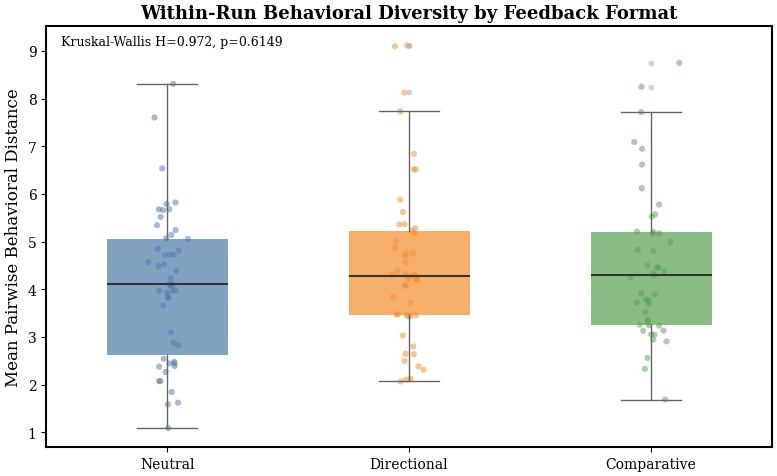


Pairwise comparisons (Mann-Whitney U + Cliff's delta):
Pair                                    U          p    Cliff d       Effect
------------------------------------------------------------------------
neutral vs directional              1127.0     0.3984     -0.098   negligible
neutral vs comparative              1011.0     0.3976     -0.101   negligible
directional vs comparative              1122.0     0.9851     -0.003   negligible


In [7]:
# Compute pairwise diversity
reliable_bf_cols = bf_cols
valid_all = df[~df["failed"]]
valid = valid_all.dropna(subset=reliable_bf_cols)
scaler = StandardScaler().fit(valid[reliable_bf_cols])

diversity_rows = []
for (cond, seed), grp in df.groupby(["condition", "seed"]):
    sub = grp[~grp["failed"]].dropna(subset=reliable_bf_cols)
    if len(sub) < 3:
        continue
    X = scaler.transform(sub[reliable_bf_cols].values)
    dists = pdist(X, metric="euclidean")
    fmt = cond.split("-", 1)[0]
    feat = cond.split("-", 1)[1]
    diversity_rows.append({
        "condition": cond,
        "format": fmt,
        "feature": feat,
        "seed": seed,
        "mean_dist": np.mean(dists),
        "median_dist": np.median(dists),
        "std_dist": np.std(dists),
        "n_valid": len(sub),
    })

div_df = pd.DataFrame(diversity_rows)
print(f"Computed diversity for {len(div_df)} runs")
print(div_df.groupby("format")["mean_dist"].describe().round(3))

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
format_data = [div_df[div_df["format"] == fmt]["mean_dist"].values for fmt in FORMATS]
bp = ax.boxplot(format_data, labels=[f.capitalize() for f in FORMATS], patch_artist=True,
                widths=0.5,
                medianprops=dict(color="#333333", linewidth=1.5),
                whiskerprops=dict(color="#666666"),
                capprops=dict(color="#666666"),
                flierprops=dict(marker="o", markerfacecolor="#bab0ac",
                                markeredgecolor="none", markersize=4, alpha=0.6))
for patch, fmt in zip(bp["boxes"], FORMATS):
    patch.set_facecolor(FORMAT_COLORS[fmt])
    patch.set_edgecolor("none")
    patch.set_alpha(0.7)

rng = np.random.default_rng(42)
for i, fmt in enumerate(FORMATS):
    vals = div_df[div_df["format"] == fmt]["mean_dist"].values
    jitter = rng.normal(0, 0.04, size=len(vals))
    ax.scatter(np.full_like(vals, i + 1) + jitter, vals,
              alpha=0.5, s=20, color=FORMAT_COLORS[fmt], edgecolor="none")

ax.set_ylabel("Mean Pairwise Behavioral Distance")
ax.set_title("Within-Run Behavioral Diversity by Feedback Format", fontweight="bold")

kw_stat, kw_p = stats.kruskal(*[d for d in format_data if len(d) > 0])
ax.text(0.02, 0.98, f"Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.4f}",
        transform=ax.transAxes, va="top", fontsize=FONT_SIZE_LEGEND)

plt.tight_layout()
plt.show()

print("\nPairwise comparisons (Mann-Whitney U + Cliff's delta):")
print(f"{'Pair':<30s} {'U':>10s} {'p':>10s} {'Cliff d':>10s} {'Effect':>12s}")
print("-" * 72)
for f1, f2 in combinations(FORMATS, 2):
    v1 = div_df[div_df["format"] == f1]["mean_dist"].values
    v2 = div_df[div_df["format"] == f2]["mean_dist"].values
    u_stat, u_p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
    cd = cliffs_delta(v1, v2)
    print(f"{f1} vs {f2:<20s} {u_stat:10.1f} {u_p:10.4f} {cd:10.3f} {effect_label(cd):>12s}")

## 5. Diversity-Performance Relationship

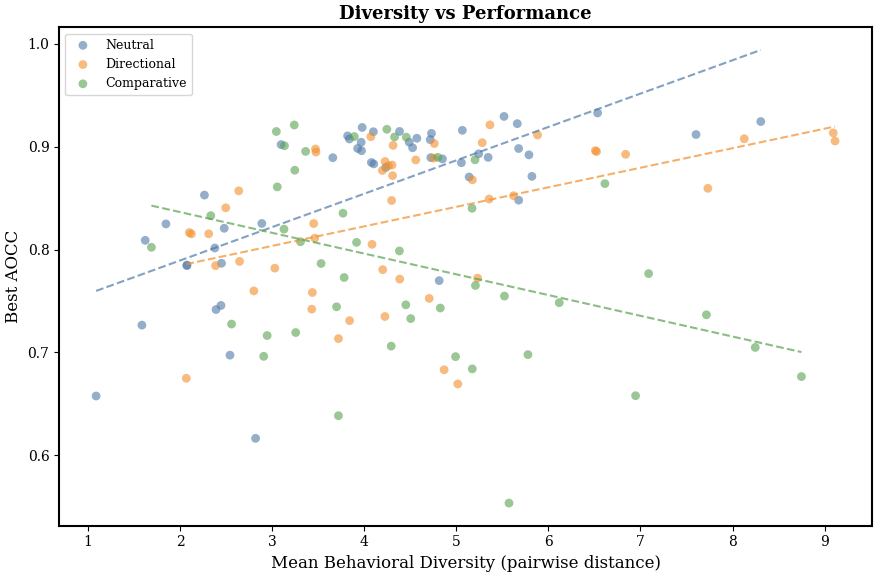


Spearman correlation: diversity vs best AOCC
Scope                     rho          p      n
--------------------------------------------
Overall                 0.259     0.0016    145
neutral                 0.620     0.0000     50
directional             0.512     0.0001     50
comparative            -0.329     0.0275     45


In [8]:
# Compute best AOCC per run and merge with diversity
best_aocc = (
    df[~df["failed"]]
    .groupby(["condition", "seed"])["fitness"]
    .max()
    .reset_index()
    .rename(columns={"fitness": "best_aocc"})
)
merged = div_df.merge(best_aocc, on=["condition", "seed"], how="inner")

fig, ax = plt.subplots(figsize=(9, 6))
for fmt in FORMATS:
    sub = merged[merged["format"] == fmt].dropna(subset=["mean_dist", "best_aocc"])
    if sub.empty:
        continue
    ax.scatter(sub["mean_dist"], sub["best_aocc"], label=fmt.capitalize(),
              color=FORMAT_COLORS[fmt], alpha=0.6, s=40, edgecolor="none")
    if len(sub) >= 3 and sub["mean_dist"].std() > 0:
        try:
            z = np.polyfit(sub["mean_dist"].values, sub["best_aocc"].values, 1)
            x_line = np.linspace(sub["mean_dist"].min(), sub["mean_dist"].max(), 100)
            ax.plot(x_line, np.polyval(z, x_line), color=FORMAT_COLORS[fmt],
                    linewidth=1.5, linestyle="--", alpha=0.7)
        except (np.linalg.LinAlgError, ValueError):
            pass

ax.set_xlabel("Mean Behavioral Diversity (pairwise distance)")
ax.set_ylabel("Best AOCC")
ax.set_title("Diversity vs Performance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nSpearman correlation: diversity vs best AOCC")
print(f"{'Scope':<20s} {'rho':>8s} {'p':>10s} {'n':>6s}")
print("-" * 44)
clean = merged.dropna(subset=["mean_dist", "best_aocc"])
rho_all, p_all = stats.spearmanr(clean["mean_dist"], clean["best_aocc"])
print(f"{'Overall':<20s} {rho_all:8.3f} {p_all:10.4f} {len(clean):6d}")
for fmt in FORMATS:
    sub = clean[clean["format"] == fmt]
    if len(sub) >= 3:
        rho, p = stats.spearmanr(sub["mean_dist"], sub["best_aocc"])
        print(f"{fmt:<20s} {rho:8.3f} {p:10.4f} {len(sub):6d}")

## 6. Summary

In [9]:
# Summary: best-candidate steering vs pairwise diversity
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print("\n--- Best-Candidate Steering ---")
print(f"Directional: best-candidate accuracy = {dir_correct_best}/{dir_total}")
print(f"             all-candidate accuracy  = {dir_correct_all}/{dir_total}")
print(f"Comparative: best-candidate accuracy = {comp_correct_best}/{comp_total}")
print(f"             all-candidate accuracy  = {comp_correct_all}/{comp_total}")
print(f"Comparative: reached top-10% ref     = {comp_reached}/{comp_total_ref}")

print("\n--- Pairwise Diversity ---")
neutral_mean_div = div_df[div_df["format"] == "neutral"]["mean_dist"].mean()
prescriptive_mean_div = div_df[div_df["format"].isin(["directional", "comparative"])]["mean_dist"].mean()
div_change_pct = (prescriptive_mean_div - neutral_mean_div) / neutral_mean_div * 100

print(f"Neutral mean diversity:      {neutral_mean_div:.3f}")
print(f"Prescriptive mean diversity: {prescriptive_mean_div:.3f} ({div_change_pct:+.1f}%)")
print(f"Kruskal-Wallis p = {kw_p:.4f}")

if kw_p >= 0.05:
    print("\nNo significant difference in aggregate pairwise diversity across formats.")
    print("The neutral advantage likely stems from other mechanisms (e.g., avoiding")
    print("misleading prescriptions) rather than from broader search space exploration.")
else:
    print(f"\nSignificant diversity difference detected (p={kw_p:.4f}).")

print("\n--- Key Findings ---")
print("1. Looking at the BEST algorithm per run rather than all candidates")
print("   provides a cleaner picture of whether feedback achieved its goal.")
print("2. The best-so-far trajectories show whether the guided feature")
print("   converged toward the target by end of run.")
print("3. Aggregate pairwise diversity is a blunt metric that mixes all")
print("   29 features equally — it does not capture targeted steering.")

SUMMARY

--- Best-Candidate Steering ---
Directional: best-candidate accuracy = 5/10
             all-candidate accuracy  = 3/10
Comparative: best-candidate accuracy = 3/9
             all-candidate accuracy  = 4/9
Comparative: reached top-10% ref     = 3/9

--- Pairwise Diversity ---
Neutral mean diversity:      4.078
Prescriptive mean diversity: 4.486 (+10.0%)
Kruskal-Wallis p = 0.6149

No significant difference in aggregate pairwise diversity across formats.
The neutral advantage likely stems from other mechanisms (e.g., avoiding
misleading prescriptions) rather than from broader search space exploration.

--- Key Findings ---
1. Looking at the BEST algorithm per run rather than all candidates
   provides a cleaner picture of whether feedback achieved its goal.
2. The best-so-far trajectories show whether the guided feature
   converged toward the target by end of run.
3. Aggregate pairwise diversity is a blunt metric that mixes all
   29 features equally — it does not capture targe